In [1]:
import os
import sys
from pathlib import Path

# Are we working on google colab?
if 'google.colab' in str(get_ipython()):
    
    from google.colab import drive
    drive.mount('/content/drive')
    
    # If so, look for the files on the drive location
    data_path = Path('/content/drive/MyDrive/TFM/data')
    
else:
    
    # If the session is running local
    root_path = Path(os.path.abspath(".."))
    
    # Add path to Python's system
    if str(root_path) not in sys.path:
        sys.path.append(str(root_path))
    
    # Create file path
    file_path = root_path / 'data' / 'intermediate' / 'clinical_data_clean.parquet'

# Introduction

In [2]:
# DATA WRANGLING, STATISTICS AND VISUALIZATION
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# MODEL SELECTION
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from optuna import visualization as vis

# MODEL EVALUATION
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, precision_recall_curve, average_precision_score

# HYPERPARAMETER TUNING
import optuna
from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, FloatDistribution, CategoricalDistribution

# Data

Load the data, check the structure and split the data into target class and features:

In [3]:
# Load data
df = pd.read_parquet(file_path)

# Check general structure
df.info()

# Features
X = df.drop("af_recurrence", axis=1)

# Target class manually encoded
y = df["af_recurrence"].map({"no":0, "yes":1})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   gender              720 non-null    category
 1   age                 720 non-null    float64 
 2   smoking_status      720 non-null    category
 3   working_status      720 non-null    category
 4   education_level     720 non-null    category
 5   household_size      720 non-null    float64 
 6   children            720 non-null    float64 
 7   marital_status      720 non-null    category
 8   cohort              720 non-null    category
 9   node                720 non-null    category
 10  bmi                 720 non-null    float64 
 11  total_met           720 non-null    float64 
 12  t2_diabetes         720 non-null    category
 13  hypolipidemics      703 non-null    category
 14  hypercholesterol    720 non-null    category
 15  hbp                 720 non-null    cate

Since the `cohort` and `node` features are meant to randomize the subjects to perform statistical analysis, it does not make any sense to use them as predictors. Therefore, they can be dropped:

In [4]:
# Drop features
X = X.drop(['cohort', 'node'], axis=1)

## Preprocessing

Divide data set into train and test set:

In [5]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
    )

Create the preprocessing pipeline:

In [6]:
# Divide features by their data type
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(include='category').columns

# Transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('cat', OneHotEncoder(handle_unknown='ignore'))
])

# Join transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Training, optimization and evaluation

## Random forest

Ensemble the model:

In [7]:
# Full pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# Hyperparameters search space
params_dist_RF = {
    'clf__n_estimators': IntDistribution(50, 300),
    'clf__max_depth': IntDistribution(2, 32),
    'clf__min_samples_split': IntDistribution(2, 20), 
    'clf__criterion': CategoricalDistribution(['gini', 'entropy']),
    'clf__class_weight': CategoricalDistribution([None, 'balanced', 'balanced_subsample'])
}

# Random search
optuna_search_RF = OptunaSearchCV(
    estimator=pipe_RF,
    param_distributions=params_dist_RF,
    n_trials=50,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

C:\Users\Miguel\AppData\Local\Temp\ipykernel_14416\53830373.py:17: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search_RF = OptunaSearchCV(


Train and optimize the model:

In [8]:
optuna_search_RF.fit(X_train, y_train)

[I 2026-04-22 10:49:19,210] A new study created in memory with name: no-name-2326fcd1-0bd3-4b39-ade4-2f408ab581c2
[I 2026-04-22 10:49:36,270] Trial 5 finished with value: 0.13403019744483158 and parameters: {'clf__n_estimators': 58, 'clf__max_depth': 30, 'clf__min_samples_split': 17, 'clf__criterion': 'gini', 'clf__class_weight': None}. Best is trial 5 with value: 0.13403019744483158.
[I 2026-04-22 10:50:00,177] Trial 3 finished with value: 0.17746806039488966 and parameters: {'clf__n_estimators': 75, 'clf__max_depth': 28, 'clf__min_samples_split': 2, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced_subsample'}. Best is trial 3 with value: 0.17746806039488966.
[I 2026-04-22 10:50:40,209] Trial 6 finished with value: 0.3444831591173055 and parameters: {'clf__n_estimators': 240, 'clf__max_depth': 10, 'clf__min_samples_split': 9, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}. Best is trial 6 with value: 0.3444831591173055.
[I 2026-04-22 10:50:40,715] Trial 7 fin

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'clf__class_weight': CategoricalDi...d_subsample')), 'clf__criterion': CategoricalDi...', 'entropy')), 'clf__max_depth': IntDistributi...low=2, step=1), 'clf__min_samples_split': IntDistributi...low=2, step=1), ...}"
,cv,5
,enable_pruning,False
,error_score,nan
,max_iter,1000
,n_jobs,-1
,n_trials,50
,random_state,42
,refit,True
,return_train_score,False


Check the optimization process along time:

In [9]:
# Get the study
study_RF = optuna_search_RF.study_

# Display the plot
fig = vis.plot_optimization_history(study_RF)
fig.show()

Evaluate the model using evaluation metrics:

In [10]:
# Extract the model with the best performance
optimized_RF = optuna_search_RF.best_estimator_

# Get predictions
y_pred_RF = optimized_RF.predict(X_test)

# Get the probabilities of the positive class
y_scores_RF = optimized_RF.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_RF = accuracy_score(y_test, y_pred_RF)
precision_RF = precision_score(y_test, y_pred_RF)
recall_RF = recall_score(y_test, y_pred_RF)
auc_RF = average_precision_score(y_test, y_pred_RF)

# Calculate the precision and recall values for the given thresholds
prec_RF, rec_RF, _ = precision_recall_curve(y_test, y_scores_RF)


Check the confusion matrix:

Text(50.722222222222214, 0.5, 'Real')

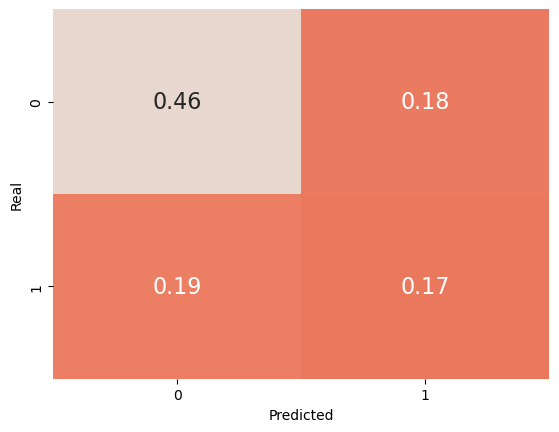

In [11]:
# Get the confusion matrix
cm_RF = confusion_matrix(y_test, y_pred_RF)/len(y_test)

# Plot confusion matrix
sns.heatmap(cm_RF, annot=True, cmap='coolwarm_r', cbar=False,
            vmin=0, vmax=1,
            xticklabels=['0', '1'],
            yticklabels=['0', '1'],
            annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('Real')

Check the precision-recall curve:

## Support Vector Machine


Ensemble the model:

In [14]:
# Full pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', SVC(random_state=42))
])

# Parameters grid
params_dist_SVM = {
    'clf__C': FloatDistribution(1e-3, 1e2, log=True),
    'clf__kernel': CategoricalDistribution(['linear', 'rbf', 'poly', 'sigmoid']),
    'clf__gamma': CategoricalDistribution(['scale', 'auto']), 
    'clf__degree': IntDistribution(2, 5),
    'clf__class_weight': CategoricalDistribution([None, 'balanced'])
}

# Random search
optuna_search_SVM = OptunaSearchCV(
    estimator=pipe_SVM,
    param_distributions=params_dist_SVM,
    n_trials=50,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

C:\Users\Miguel\AppData\Local\Temp\ipykernel_14416\3913796483.py:17: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search_SVM = OptunaSearchCV(


Train and optimize the model:

In [15]:
optuna_search_SVM.fit(X_train, y_train)

[I 2026-04-22 10:57:20,149] A new study created in memory with name: no-name-c9c8bc1a-a6fd-4684-b066-d6878ecd2277
[I 2026-04-22 10:57:24,429] Trial 2 finished with value: 0.4020905923344948 and parameters: {'clf__C': 63.855226457672785, 'clf__kernel': 'rbf', 'clf__gamma': 'auto', 'clf__degree': 5, 'clf__class_weight': None}. Best is trial 2 with value: 0.4020905923344948.
[I 2026-04-22 10:57:24,443] Trial 1 finished with value: 0.009523809523809523 and parameters: {'clf__C': 0.048871315737549784, 'clf__kernel': 'poly', 'clf__gamma': 'auto', 'clf__degree': 2, 'clf__class_weight': None}. Best is trial 2 with value: 0.4020905923344948.
[I 2026-04-22 10:57:24,501] Trial 5 finished with value: 0.478281068524971 and parameters: {'clf__C': 2.5521626657495284, 'clf__kernel': 'rbf', 'clf__gamma': 'scale', 'clf__degree': 5, 'clf__class_weight': 'balanced'}. Best is trial 5 with value: 0.478281068524971.
[I 2026-04-22 10:57:24,653] Trial 0 finished with value: 0.5500580720092916 and parameters: {

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'clf__C': FloatDistribu...01, step=None), 'clf__class_weight': CategoricalDi..., 'balanced')), 'clf__degree': IntDistributi...low=2, step=1), 'clf__gamma': CategoricalDi...ale', 'auto')), ...}"
,cv,5
,enable_pruning,False
,error_score,nan
,max_iter,1000
,n_jobs,-1
,n_trials,50
,random_state,42
,refit,True
,return_train_score,False


Time:

In [16]:
# Get the study
study_SVM = optuna_search_SVM.study_

# Display the plot
fig = vis.plot_optimization_history(study_SVM)
fig.show()

Evaluate the model:

In [17]:
# Extract the optimized model
optimized_SVM = optuna_search_SVM.best_estimator_

# Make predictions
y_pred_SVM = optimized_RF.predict(X_test)

# Get the probabilities of the positive class
y_scores_SVM = optimized_SVM.decision_function(X_test)

# Calculate evaluation metrics
accuracy_SVM = accuracy_score(y_test, y_pred_SVM)
precision_SVM = precision_score(y_test, y_pred_SVM)
recall_SVM = recall_score(y_test, y_pred_SVM)
auc_SVM = average_precision_score(y_test, y_pred_SVM)

# Calculate the precision and recall values for the given thresholds
prec_SVM, rec_SVM, _ = precision_recall_curve(y_test, y_scores_SVM)

Text(50.722222222222214, 0.5, 'Real')

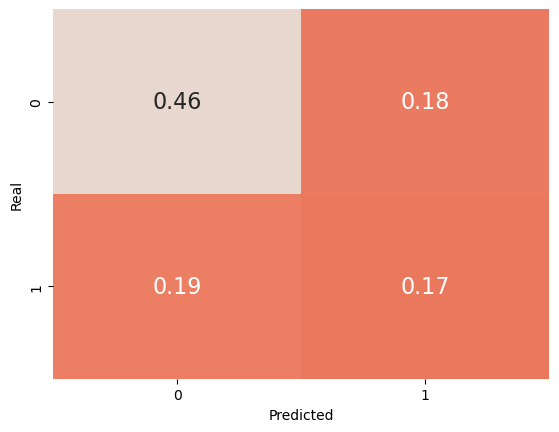

In [18]:
# Get the confusion matrix
cm_SVM = confusion_matrix(y_test, y_pred_SVM)/len(y_test)

# Plot confusion matrix
sns.heatmap(cm_RF, annot=True, cmap='coolwarm_r', cbar=False,
            vmin=0, vmax=1,
            xticklabels=['0', '1'],
            yticklabels=['0', '1'],
            annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('Real')

## K-Nearest Neighbors

In [19]:
# Full pipeline
pipe_KNN = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier())
])

# Parameters grid
params_dist_KNN = {
    'clf__n_neighbors': IntDistribution(3, 50),
    'clf__weights': CategoricalDistribution(['uniform', 'distance']),
    'clf__p': IntDistribution(1, 2),
    'clf__algorithm': CategoricalDistribution(['auto', 'ball_tree', 'kd_tree', 'brute'])
}

# Random search
optuna_search_KNN = OptunaSearchCV(
    estimator=pipe_KNN,
    param_distributions=params_dist_KNN,
    n_trials=50,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

C:\Users\Miguel\AppData\Local\Temp\ipykernel_14416\2511157716.py:16: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search_KNN = OptunaSearchCV(


Train and optimize the model:

In [20]:
optuna_search_KNN.fit(X_train, y_train)

[I 2026-04-22 10:58:07,034] A new study created in memory with name: no-name-2154925a-0ece-48c5-ade0-080cca5d3fa6
[I 2026-04-22 10:58:09,394] Trial 4 finished with value: 0.03809523809523809 and parameters: {'clf__n_neighbors': 34, 'clf__weights': 'distance', 'clf__p': 2, 'clf__algorithm': 'kd_tree'}. Best is trial 4 with value: 0.03809523809523809.
c:\Users\Miguel\miniconda3\envs\tfm\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
[I 2026-04-22 10:58:17,584] Trial 5 finished with value: 0.014285714285714285 and parameters: {'clf__n_neigh

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'clf__algorithm': CategoricalDi...ee', 'brute')), 'clf__n_neighbors': IntDistributi...low=3, step=1), 'clf__p': IntDistributi...low=1, step=1), 'clf__weights': CategoricalDi..., 'distance'))}"
,cv,5
,enable_pruning,False
,error_score,nan
,max_iter,1000
,n_jobs,-1
,n_trials,50
,random_state,42
,refit,True
,return_train_score,False


In [21]:
# Get the study
study_KNN = optuna_search_KNN.study_

# Display the plot
fig = vis.plot_optimization_history(study_KNN)
fig.show()

Evaluate the model:

In [22]:
# Extract the optimized model
optimized_KNN = optuna_search_KNN.best_estimator_

# Make predictions
y_pred_KNN = optimized_KNN.predict(X_test)

# Get the probabilities of the positive class
y_scores_KNN = optimized_KNN.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_KNN = accuracy_score(y_test, y_pred_KNN)
precision_KNN = precision_score(y_test, y_pred_KNN)
recall_KNN = recall_score(y_test, y_pred_KNN)
auc_KNN = average_precision_score(y_test, y_pred_KNN)

# Calculate the precision and recall values for the given thresholds
prec_KNN, rec_KNN, _ = precision_recall_curve(y_test, y_scores_KNN)

Text(50.722222222222214, 0.5, 'Real')

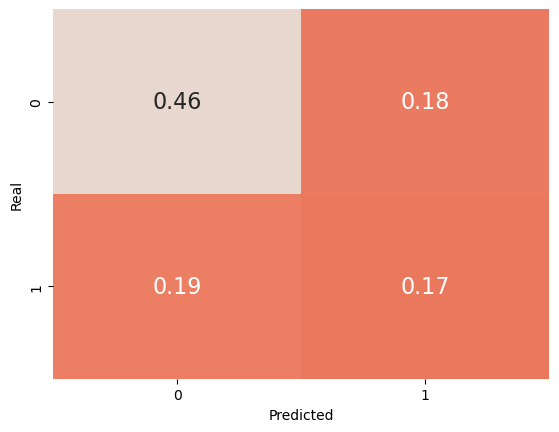

In [23]:
# Get the confusion matrix
cm_SVM = confusion_matrix(y_test, y_pred_SVM)/len(y_test)

# Plot confusion matrix
sns.heatmap(cm_RF, annot=True, cmap='coolwarm_r', cbar=False,
            vmin=0, vmax=1,
            xticklabels=['0', '1'],
            yticklabels=['0', '1'],
            annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('Real')

Evaluate the precision-recall curve:

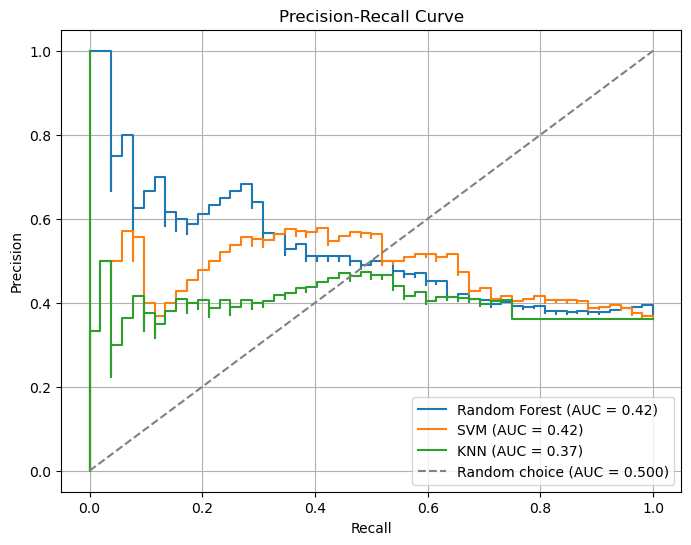

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(rec_RF, prec_RF, label=f'RF (AUC = {auc_RF:.2f})', drawstyle='steps-post')
plt.plot(rec_SVM, prec_SVM, label=f'SVM (AUC = {auc_SVM:.2f})', drawstyle='steps-post')
plt.plot(rec_KNN, prec_KNN, label=f'KNN (AUC = {auc_KNN:.2f})', drawstyle='steps-post')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random choice (AUC = 0.500)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

Evaluate the recall:

<Figure size 1000x600 with 0 Axes>

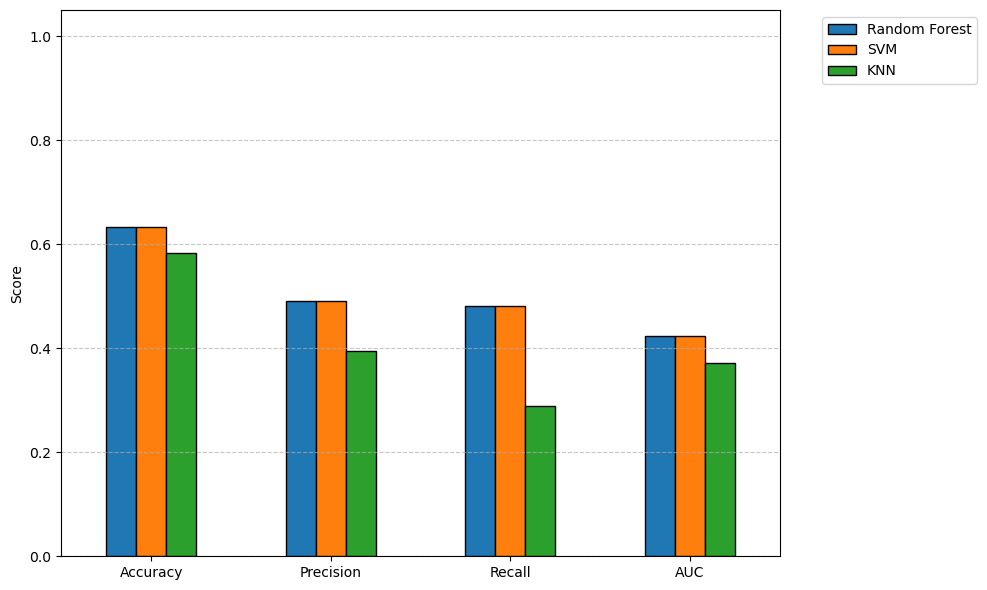

In [36]:
# Specify categories and values
categories = ['Accuracy', 'Precision', 'Recall', 'AUC']
values_RF = [accuracy_RF, precision_RF, recall_RF, auc_RF]
values_SVM = [accuracy_SVM, precision_SVM, recall_SVM, auc_SVM]
values_KNN = [accuracy_KNN, precision_KNN, recall_KNN, auc_KNN]

# Build data frame
df_metricas = pd.DataFrame({
    'Random Forest': values_RF,
    'SVM': values_SVM,
    'KNN': values_KNN
}, index=categories)

plt.figure(figsize=(10, 6))

ax = df_metricas.plot(kind='bar', figsize=(10, 6), edgecolor='black', rot=0, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()